# Assignment 5

Deadline: xx.xx.2026 12:00 CEST

## Task

Develop an investment strategy for the Swiss equity market, backtest it using the provided datasets (i.e., `market_data.parquet`, `jkp_data.parquet`, `spi_index.csv`) and analyze its performance by benchmarking it against the Swiss Performance Index (SPI). Build on the existing qpmwp-course codebase and extend it with any additional components required. Summarize your approach and findings in a written report.

### Coding (15 points)



- Selection:
  Use some of the existing selection item builder functions (in `bibfn_selection.py`, applied via `SelectionItemBuilder`) to filter stocks based on specific criteria, and/or implement your own filters (e.g., exclude low-quality or high-volatility stocks).

- Optimization Data & Constraints:
  Use the implemented functions for preparing optimization inputs (in `bibfn_optimization_data.py`, applied via `OptimizationItemBuilder`) and for specifying constraints such as stock, sector, or factor exposure limits (in `bibfn_constraints.py`, applied via `OptimizationItemBuilder`). Extend these with your own functions where appropriate.

- Signal Generation:
  Use a machine learning method to estimate optimization inputs such as expected returns or risk. Possible approaches include regression, classification, or learning-to-rank models. A good starting point is the demo notebook `xsection_regressor.ipynb` which shows how to generate predictive signals. Use jkp_data as features or engineer your own (e.g., technical indicators from returns or prices). Alternatively, or in combination, you may use a factor model to construct the optimization inputs.

- Optimization Model:
  Use an optimization model to determine portfolio weights. You may rely on an existing class (e.g., `MeanVariance`, `LeastSquares`, or `BlackLitterman`) or implement a custom model. If you choose to create a custom optimization model, develop a class inheriting from `Optimization` and ensure implement the methods `set_objective` (to construct the coefficients of the objective function) and `solve` (to run the optimization).

- Simulation:
  Backtest the strategy and simulate portfolio returns, incorporating fixed costs of 1% per year and transaction costs of 0.2% per rebalancing.


### Report (15 points):

Produce an HTML report (for example, by converting a .ipynb notebook to HTML) containing:

- High-level strategy overview: A clear description of the investment strategy and its rationale.

- Detailed explanation of the backtesting steps: A step-by-step explanation of the backtest design, including model choices and implementation details (e.g., the machine learning method or factor model used).

- Backtesting results:
    
    - Charts: Visualizations such as cumulative performance, rolling 3-year returns, etc.
    - Descriptive statistics: Key statistics such as mean, standard deviation, drawdown, turnover, and Sharpe ratio (or any other relevant metric) for the full backtest period as well as for subperiods (e.g., the last 5 years, or during bull vs. bear market phases).
    - Compare your strategy against the SPI.


## Imports and paths

In [17]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent

src_path = project_root / 'src'
sys.path.append(str(project_root))
sys.path.append(str(src_path))

from helper_functions import load_data_spi, align_market_data_with_jkp_data
from estimation.covariance import Covariance
from optimization.optimization import BlackLitterman
from backtesting.backtest_item_builder.bib_classes import SelectionItemBuilder, OptimizationItemBuilder
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_min_volume,
    bibfn_selection_jkp_data_scores,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
    bibfn_scores,
    bibfn_cap_weights,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

PATH_TO_DATA = project_root / 'data'
SAVE_PATH = project_root / 'output'
SAVE_PATH.mkdir(exist_ok=True)

np.random.seed(42)

## Load data

In [18]:
market_data = pd.read_parquet(PATH_TO_DATA / 'market_data.parquet')
jkp_data = pd.read_parquet(PATH_TO_DATA / 'jkp_data.parquet')
spi = load_data_spi(path=str(PATH_TO_DATA))

market_data_ffill, jkp_data = align_market_data_with_jkp_data(
    market_data=market_data,
    jkp_data=jkp_data,
)

data = BacktestData()
data.market_data = market_data_ffill
data.jkp_data = jkp_data
data.bm_series = spi

## Rebalancing dates

In [19]:
n_month = 3
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique()
    .sort_values()
)

rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data.index.get_level_values('date').min()
    ][::n_month]
    .strftime('%Y-%m-%d')
    .tolist()
)

rebdates = [date for date in rebdates if date > '2002-01-01' and date < rebdates[-1]]
rebdates[:5], rebdates[-5:]

(['2002-01-31', '2002-04-30', '2002-07-31', '2002-10-31', '2003-01-31'],
 ['2022-10-31', '2023-01-31', '2023-04-30', '2023-07-31', '2023-10-31'])

## Strategy rationale

The strategy uses a cross-sectional machine learning signal based on value, momentum, profitability, investment, quality, leverage, and low-risk characteristics. The signal is used as a Black-Litterman view. The portfolio is long-only, fully invested, liquidity-filtered, and benchmarked against the Swiss Performance Index.

## Machine learning signal generation

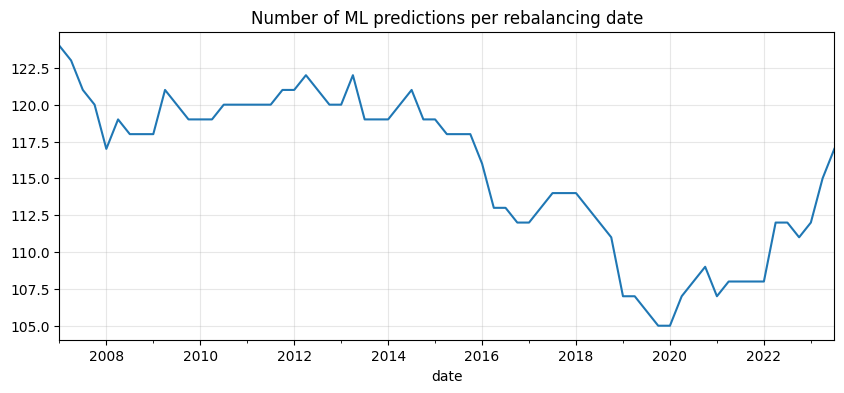

In [20]:
FEATURE_COLS = [
    'ret_6_1',
    'ret_12_1',
    'prc_highprc_252d',
    'be_me',
    'at_me',
    'fcf_me',
    'ocf_me',
    'sale_me',
    'gp_at',
    'op_at',
    'qmj',
    'qmj_prof',
    'qmj_growth',
    'qmj_safety',
    'at_gr1',
    'inv_gr1a',
    'oaccruals_at',
    'debt_me',
    'beta_60m',
    'ivol_ff3_21d',
]

feature_cols = [col for col in FEATURE_COLS if col in jkp_data.columns]

prices = market_data_ffill.pivot_table(
    index='date',
    columns='id',
    values='price',
).sort_index()

grid_dates = pd.to_datetime(rebdates)
grid_prices = prices.reindex(grid_dates, method='ffill')
forward_returns = grid_prices.pct_change().shift(-1)

def get_features_at_date(date):
    date = pd.to_datetime(date)
    df = jkp_data[feature_cols]
    df = df.loc[
        (df.index.get_level_values('date') <= date) &
        (df.index.get_level_values('date') >= date - pd.Timedelta(days=365))
    ]
    df = df.groupby('id').last()
    return df

X_by_date = {}
for date in grid_dates:
    X_by_date[date] = get_features_at_date(date)

train_window = 20
predictions = {}

model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10.0)),
])

for i in range(train_window, len(grid_dates) - 1):
    pred_date = grid_dates[i]
    train_dates = grid_dates[i - train_window:i]

    X_train_list = []
    y_train_list = []

    for train_date in train_dates:
        X_tmp = X_by_date[train_date]
        y_tmp = forward_returns.loc[train_date]
        common_ids = X_tmp.index.intersection(y_tmp.dropna().index)

        X_train_list.append(X_tmp.loc[common_ids])
        y_train_list.append(y_tmp.loc[common_ids])

    X_train = pd.concat(X_train_list, axis=0)
    y_train = pd.concat(y_train_list, axis=0)

    train_data = X_train.copy()
    train_data['target'] = y_train.values
    train_data = train_data.replace([np.inf, -np.inf], np.nan).dropna()

    X_pred = X_by_date[pred_date].replace([np.inf, -np.inf], np.nan).dropna()

    model.fit(train_data[feature_cols], train_data['target'])
    predictions[pred_date] = pd.Series(
        model.predict(X_pred[feature_cols]),
        index=X_pred.index,
        name=pred_date,
    )

ml_signal = pd.DataFrame(predictions).T
ml_signal.index.name = 'date'
ml_signal.columns.name = 'id'
ml_signal_path = SAVE_PATH / 'ml_signal_ridge.parquet'
ml_signal.to_parquet(ml_signal_path)

ml_signal_stack = ml_signal.stack().rename('ml_signal').astype('float64')
ml_signal_stack.index.names = jkp_data.index.names

jkp_data_ml = jkp_data.join(ml_signal_stack, how='left')
data.jkp_data = jkp_data_ml

ml_signal.count(axis=1).plot(title='Number of ML predictions per rebalancing date', figsize=(10, 4))
plt.grid(alpha=0.3)
plt.show()

## Backtest setup

In [21]:
JKP_FIELDS_ML = ['ml_signal']

selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365,
        min_volume=500_000,
        agg_fn=np.median,
    ),
    'jkp_data_scores': SelectionItemBuilder(
        bibfn=bibfn_selection_jkp_data_scores,
        fields=JKP_FIELDS_ML,
    ),
}

optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fillna_value=0,
    ),
    'scores': OptimizationItemBuilder(
        bibfn=bibfn_scores,
        fields=JKP_FIELDS_ML,
    ),
    'cap_weights': OptimizationItemBuilder(
        bibfn=bibfn_cap_weights,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1,
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        lower=0,
        upper=0.05,
        box_type='LongOnly',
    ),
}

optimization = BlackLitterman(
    solver_name='cvxopt',
    covariance=Covariance(method='pearson', check_positive_definite=True),
    tau_psi=0.01,
    tau_omega=0.00001,
    view_gen_algo='quintile_sort',
    signal_names=JKP_FIELDS_ML,
)

bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    optimization=optimization,
    rebdates=[date for date in rebdates if pd.to_datetime(date) in ml_signal.index],
    quiet=True,
)

## Run backtest

In [22]:
bt_ml_bl = Backtest()
bt_ml_bl.run(bs=bs)

bt_ml_bl.save(
    path=str(SAVE_PATH),
    filename='assignment_5_ml_black_litterman.pickle',
)

Backtest object saved successfully to c:\Users\marce\Desktop\qpmwp-course\output\assignment_5_ml_black_litterman.pickle


## Simulate gross and net returns

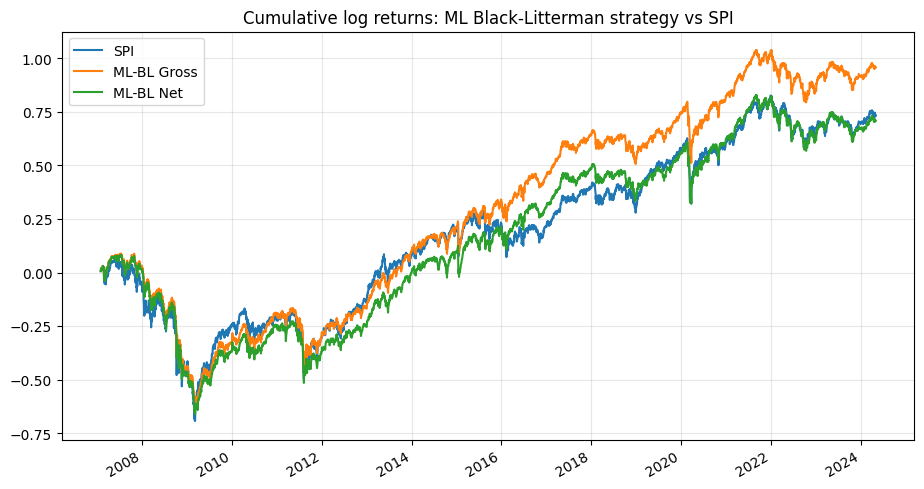

In [23]:
return_series = data.get_return_series(weekdays_only=False)

strategy_gross = bt_ml_bl.strategy.simulate(
    return_series=return_series,
    fc=0,
    vc=0,
)

strategy_net = bt_ml_bl.strategy.simulate(
    return_series=return_series,
    fc=0.01,
    vc=0,
)

turnover = bt_ml_bl.strategy.turnover(
    return_series=return_series,
    rescale=False,
)

variable_costs = turnover * 0.002
common_cost_dates = strategy_net.index.intersection(variable_costs.index)

strategy_net.loc[common_cost_dates] = (
    strategy_net.loc[common_cost_dates]
    - variable_costs.loc[common_cost_dates]
)

sim = pd.concat({
    'SPI': data.bm_series,
    'ML-BL Gross': strategy_gross,
    'ML-BL Net': strategy_net,
}, axis=1).dropna()

np.log(1 + sim).cumsum().plot(
    title='Cumulative log returns: ML Black-Litterman strategy vs SPI',
    figsize=(11, 6),
)

plt.grid(alpha=0.3)
plt.show()

## Rolling returns and drawdowns

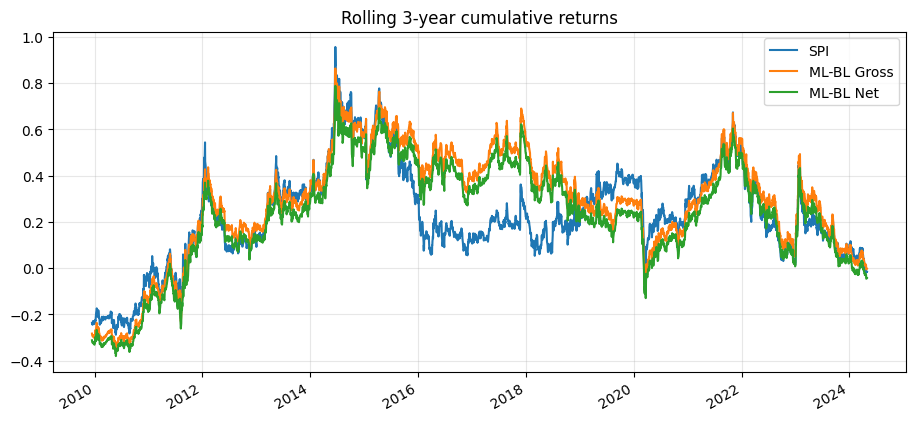

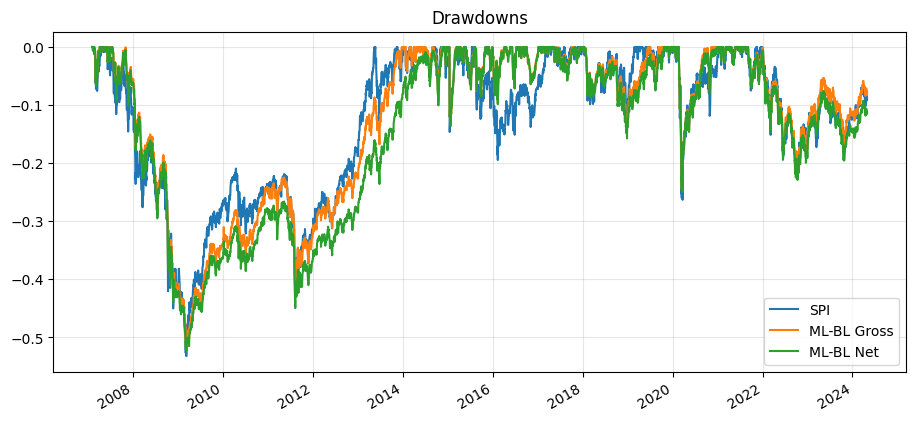

In [24]:
rolling_3y_returns = (1 + sim).rolling(252 * 3).apply(np.prod, raw=True) - 1
rolling_3y_returns.plot(
    title='Rolling 3-year cumulative returns',
    figsize=(11, 5),
)
plt.grid(alpha=0.3)
plt.show()

wealth = (1 + sim).cumprod()
drawdowns = wealth / wealth.cummax() - 1
drawdowns.plot(
    title='Drawdowns',
    figsize=(11, 5),
)
plt.grid(alpha=0.3)
plt.show()

## Performance statistics

In [25]:
def performance_stats(returns, benchmark_col='SPI', periods_per_year=252):
    stats = {}
    for col in returns.columns:
        r = returns[col].dropna()
        wealth = (1 + r).cumprod()
        drawdown = wealth / wealth.cummax() - 1

        stats[col] = {
            'Annual Return': (1 + r).prod() ** (periods_per_year / len(r)) - 1,
            'Annual Volatility': r.std() * np.sqrt(periods_per_year),
            'Sharpe Ratio': r.mean() / r.std() * np.sqrt(periods_per_year),
            'Cumulative Return': wealth.iloc[-1] - 1,
            'Max Drawdown': drawdown.min(),
        }

        if col != benchmark_col:
            active = (returns[col] - returns[benchmark_col]).dropna()
            stats[col]['Tracking Error'] = active.std() * np.sqrt(periods_per_year)
            stats[col]['Information Ratio'] = active.mean() / active.std() * np.sqrt(periods_per_year)
        else:
            stats[col]['Tracking Error'] = np.nan
            stats[col]['Information Ratio'] = np.nan

    return pd.DataFrame(stats).T

full_period_stats = performance_stats(sim)
full_period_stats

,Annual Return,Annual Volatility,Sharpe Ratio,Cumulative Return,Max Drawdown,Tracking Error,Information Ratio
SPI,0.041364,0.162443,0.330934,1.080523,-0.532487,NaN,NaN
ML-BL Gross,0.054437,0.130687,0.471233,1.606782,-0.512778,0.072473,0.107986
ML-BL Net,0.040030,0.130696,0.365931,1.032860,-0.524244,0.072482,-0.081844


## Turnover

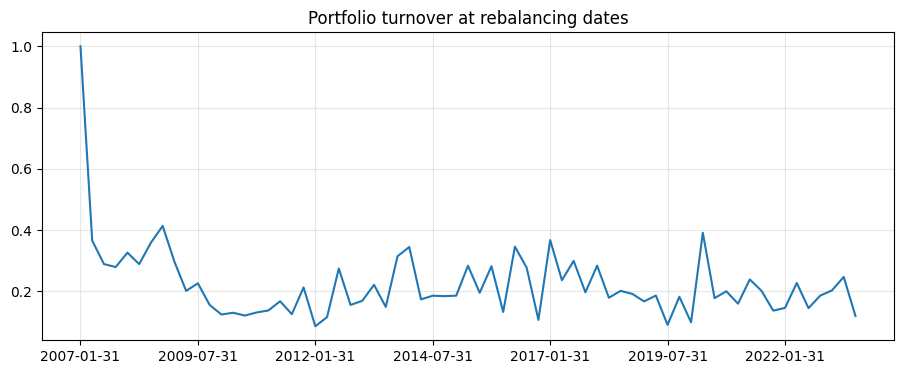

,Mean Turnover,Median Turnover,Max Turnover
0,0.22388,0.195367,1.0


In [26]:
turnover = bt_ml_bl.strategy.turnover(
    return_series=return_series,
    rescale=False,
)

turnover.plot(
    title='Portfolio turnover at rebalancing dates',
    figsize=(11, 4),
)
plt.grid(alpha=0.3)
plt.show()

turnover_summary = pd.DataFrame({
    'Mean Turnover': [turnover.mean()],
    'Median Turnover': [turnover.median()],
    'Max Turnover': [turnover.max()],
})
turnover_summary

## Subperiod statistics

In [27]:
split_date = sim.index.max() - pd.DateOffset(years=5)

early_period_stats = performance_stats(sim.loc[sim.index < split_date])
last_5y_stats = performance_stats(sim.loc[sim.index >= split_date])

subperiod_stats = pd.concat({
    'Full period': full_period_stats,
    'Before last 5 years': early_period_stats,
    'Last 5 years': last_5y_stats,
}, axis=0)

subperiod_stats

Annual Return  Annual Volatility  \
Full period         SPI               0.041364           0.162443   
                    ML-BL Gross       0.054437           0.130687   
                    ML-BL Net         0.040030           0.130696   
Before last 5 years SPI               0.038152           0.168765   
                    ML-BL Gross       0.050872           0.130427   
                    ML-BL Net         0.036509           0.130435   
Last 5 years        SPI               0.049252           0.145912   
                    ML-BL Gross       0.063196           0.131368   
                    ML-BL Net         0.048679           0.131378   

                                 Sharpe Ratio  Cumulative Return  \
Full period         SPI              0.330934           1.080523   
                    ML-BL Gross      0.471233           1.606782   
                    ML-BL Net        0.365931           1.032860   
Before last 5 years SPI              0.306369           0.616420   
                    ML-BL Gross      0.445917           0.889666   
                    ML-BL Net        0.340379           0.583921   
Last 5 years        SPI              0.402812           0.287118   
                    ML-BL Gross      0.532471           0.379494   
                    ML-BL Net        0.427779           0.283435   

                                 Max Drawdown  Tracking Error  \
Full period         SPI             -0.532487             NaN   
                    ML-BL Gross     -0.512778        0.072473   
                    ML-BL Net       -0.524244        0.072482   
Before last 5 years SPI             -0.532487             NaN   
                    ML-BL Gross     -0.512778        0.077762   
                    ML-BL Net       -0.524244        0.077766   
Last 5 years        SPI             -0.263289             NaN   
                    ML-BL Gross     -0.248528        0.057570   
                    ML-BL Net       -0.249525        0.057596   

                                 Information Ratio  
Full period         SPI                        NaN  
                    ML-BL Gross           0.107986  
                    ML-BL Net            -0.081844  
Before last 5 years SPI                        NaN  
                    ML-BL Gross           0.083014  
                    ML-BL Net            -0.093960  
Last 5 years        SPI                        NaN  
                    ML-BL Gross           0.194107  
                    ML-BL Net            -0.044694

## Calendar-year returns

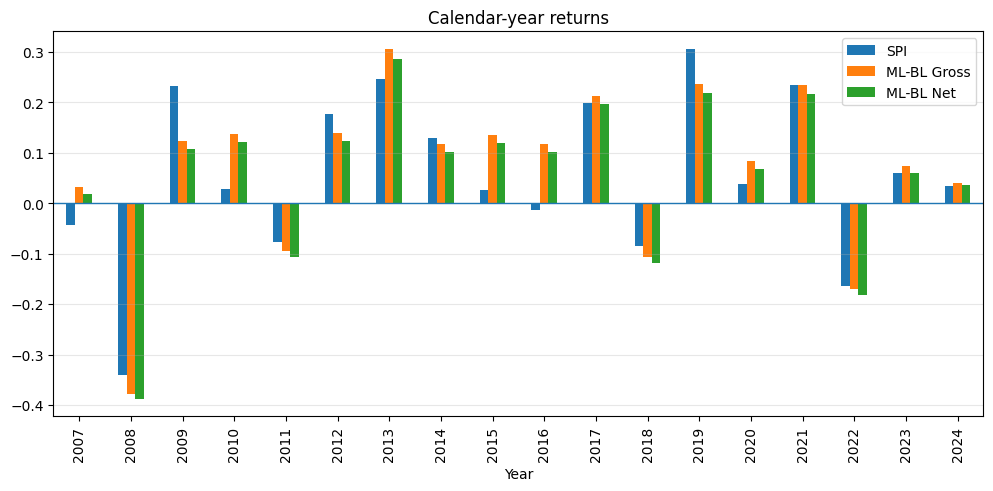

,SPI,ML-BL Gross,ML-BL Net
Year,,,
2007,-0.043683,0.032645,0.019155
2008,-0.340465,-0.379140,-0.388064
2009,0.231815,0.122691,0.106629
2010,0.029187,0.137627,0.121363
2011,-0.077211,-0.094181,-0.107156
2012,0.177224,0.139542,0.123195
2013,0.246002,0.305435,0.286769
2014,0.130012,0.118499,0.102496
2015,0.026752,0.136083,0.119836


In [28]:
calendar_year_returns = sim.groupby(sim.index.year).apply(lambda x: (1 + x).prod() - 1)
calendar_year_returns.index.name = 'Year'

calendar_year_returns.plot(
    kind='bar',
    title='Calendar-year returns',
    figsize=(12, 5),
)
plt.axhline(0, linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.show()

calendar_year_returns

## Benchmark comparison

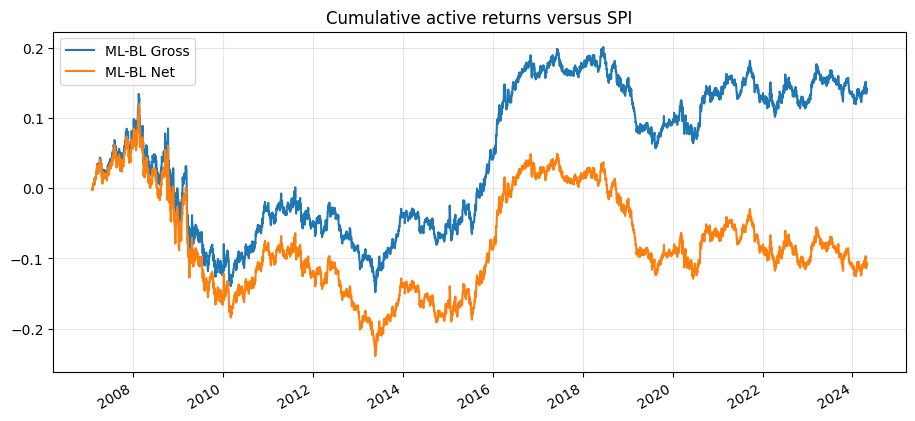

,Mean Daily Active Return,Annualized Active Return,Tracking Error,Information Ratio
ML-BL Gross,0.000031,0.007826,0.072473,0.107986
ML-BL Net,-0.000024,-0.005932,0.072482,-0.081844


In [29]:
active_returns = sim[['ML-BL Gross', 'ML-BL Net']].sub(sim['SPI'], axis=0)

active_returns.cumsum().plot(
    title='Cumulative active returns versus SPI',
    figsize=(11, 5),
)
plt.grid(alpha=0.3)
plt.show()

active_summary = pd.DataFrame({
    'Mean Daily Active Return': active_returns.mean(),
    'Annualized Active Return': active_returns.mean() * 252,
    'Tracking Error': active_returns.std() * np.sqrt(252),
    'Information Ratio': active_returns.mean() / active_returns.std() * np.sqrt(252),
})

active_summary

## Portfolio concentration

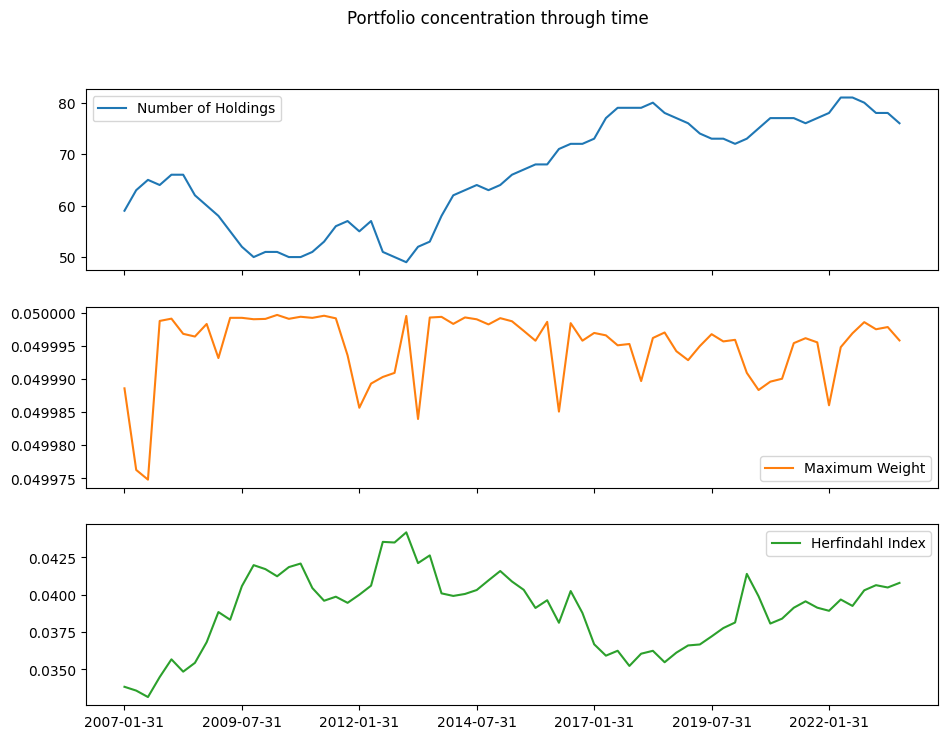

,Number of Holdings,Maximum Weight,Herfindahl Index
count,67.000000,67.000000,67.000000
mean,66.238806,0.049995,0.038960
std,10.417191,0.000005,0.002548
min,49.000000,0.049975,0.033143
25%,57.000000,0.049993,0.036749
50%,66.000000,0.049997,0.039557
75%,76.500000,0.049999,0.040592
max,81.000000,0.050000,0.044181


In [30]:
weights = bt_ml_bl.strategy.get_weights_df().fillna(0)

n_holdings = (weights > 0).sum(axis=1)
max_weight = weights.max(axis=1)
herfindahl = (weights ** 2).sum(axis=1)

portfolio_concentration = pd.concat({
    'Number of Holdings': n_holdings,
    'Maximum Weight': max_weight,
    'Herfindahl Index': herfindahl,
}, axis=1)

portfolio_concentration.plot(
    subplots=True,
    title='Portfolio concentration through time',
    figsize=(11, 8),
)
plt.show()

portfolio_concentration.describe()

## Summary

The strategy combines a cross-sectional Ridge regression signal with a Black-Litterman optimizer. The machine learning model predicts next-quarter stock returns from accounting, valuation, profitability, momentum, quality, investment, leverage, beta, and idiosyncratic-volatility characteristics. The optimizer uses the ML signal as a return view, market-cap weights as the prior, and a three-year covariance matrix for risk estimation. The portfolio is long-only, fully invested, liquidity-filtered, capped at 5% per stock, and rebalanced quarterly. Gross and net performance are compared against the Swiss Performance Index. Net returns include 1% annual fixed costs and 0.2% transaction costs applied to turnover at rebalancing dates.

## Export instruction

In [31]:
# Run in terminal from the project root to create the HTML report:
# jupyter nbconvert --to html assignments/assignment_5.ipynb --output assignment_5_report.html